In [3]:
# ============================================================
# DATA LOADING AND RANDOM TRAINING/VALIDATION/TEST PARTITIONING
# ============================================================

import numpy as np
import torch
import torch.nn as nn

from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader
from scipy.stats import pearsonr
from sklearn.preprocessing import StandardScaler

In [4]:


# ============================================================
# EXPERIMENTAL CONFIGURATION
# ============================================================

# Define the mini-batch size used during model training and
# evaluation. A relatively small batch size is selected to
# balance computational efficiency and memory requirements.
BATCH_SIZE = 16

# Select the available computational device. Apple's Metal
# Performance Shaders (MPS) backend is used when available;
# otherwise, computation falls back to the CPU.
device = torch.device(
    "mps" if torch.backends.mps.is_available() else "cpu"
)

print("Device:", device)


# ============================================================
# LOAD PRECOMPUTED DRUG–TARGET FEATURES
# ============================================================

# Load the ligand representations from disk. The ligand features
# consist of precomputed numerical molecular representations
# (e.g., 1,024-dimensional Morgan fingerprints).
#
# Memory mapping is used to avoid loading the complete dataset
# into physical memory at once, which is particularly useful
# when working with large drug–target interaction datasets.
X_lig = np.load(
    "data/processed_features/X_lig.npy",
    mmap_mode="r"
)

# Load the corresponding protein representations. Each row
# represents the numerical feature vector associated with the
# protein target of the corresponding drug–target interaction.
X_prot = np.load(
    "data/processed_features/X_prot.npy",
    mmap_mode="r"
)

# Load the continuous response variable. In the present study,
# y represents the experimentally derived drug–target binding
# affinity expressed as pKi.
y = np.load(
    "data/processed_features/y.npy",
    mmap_mode="r"
)


# Inspect the dimensionality of the feature matrices to verify
# that the number of ligand and protein observations is
# consistent before model development.
print("Ligand shape:", X_lig.shape)
print("Protein shape:", X_prot.shape)
print("Target shape:", y.shape)


# ============================================================
# RANDOM DATA PARTITIONING
# ============================================================

# First, partition the complete dataset into an 80% development
# set and a 20% independent test set.
#
# The test set is retained for final model evaluation and should
# not be used during model fitting or hyperparameter optimisation.
#
# A fixed random_state is used to ensure that the partitioning
# process is reproducible across repeated experiments.
(
    Xl_train,
    Xl_test,
    Xp_train,
    Xp_test,
    y_train,
    y_test
) = train_test_split(
    X_lig,
    X_prot,
    y,
    test_size=0.20,
    random_state=42
)


# The initial training partition is subsequently divided into
# training and validation subsets. Here, 20% of the original
# 80% development partition is allocated to validation.
#
# Consequently, the final approximate proportions of the complete
# dataset are:
#
#     Training set   = 64%
#     Validation set = 16%
#     Test set       = 20%
#
# The validation set is intended for model selection,
# hyperparameter optimisation, learning-rate adjustment, and
# early-stopping decisions, while the training set is used for
# parameter estimation.
(
    Xl_train,
    Xl_val,
    Xp_train,
    Xp_val,
    y_train,
    y_val
) = train_test_split(
    Xl_train,
    Xp_train,
    y_train,
    test_size=0.20,
    random_state=42
)


# ============================================================
# VERIFY FINAL DATA PARTITIONS
# ============================================================

# Report the number of observations assigned to each subset.
# These checks confirm that the ligand, protein, and affinity
# arrays remain correctly aligned following partitioning.
print("\nFinal dataset partition:")
print("Training samples:", len(y_train))
print("Validation samples:", len(y_val))
print("Test samples:", len(y_test))

Device: mps
Ligand shape: (148111, 1024)
Protein shape: (148111, 320)
Target shape: (148111,)

Final dataset partition:
Training samples: 94790
Validation samples: 23698
Test samples: 29623


In [26]:
RANDOM_STATE = 42
BATCH_SIZE = 16

SPLIT_FILE = "data/processed_features/fixed_split_indices.npz"

device = torch.device(
    "mps" if torch.backends.mps.is_available()
    else "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("Device:", device)

Device: mps


In [27]:

# ============================================================
# 2. LOAD CURATED BINDINGDB FEATURES
# ============================================================

X_lig = np.load(
    "data/processed_features/X_lig.npy",
    mmap_mode="r"
)

X_prot = np.load(
    "data/processed_features/X_prot.npy",
    mmap_mode="r"
)

y = np.load(
    "data/processed_features/y.npy",
    mmap_mode="r"
)

print("\nDataset:")
print("Ligand shape :", X_lig.shape)
print("Protein shape:", X_prot.shape)
print("Target shape :", y.shape)


Dataset:
Ligand shape : (148111, 1024)
Protein shape: (148111, 320)
Target shape : (148111,)


In [28]:
# ------------------------------------------------------------
# Check alignment
# ------------------------------------------------------------

assert len(X_lig) == len(X_prot) == len(y), (
    "Ligand, protein and target arrays are not aligned."
)

N = len(y)

print("Total samples:", N)

Total samples: 148111


In [29]:
import os

# ============================================================
# 3. CREATE FIXED INDICES
# ============================================================
#
# IMPORTANT:
# We split INDICES rather than X_lig, X_prot and y directly.
#
# This means exactly the same observations can be supplied to
# every machine-learning and deep-learning model.
#
# Final split:
#
# Training   = 64%
# Validation = 16%
# Test       = 20%
#
# ============================================================

if os.path.exists(SPLIT_FILE):

    print("\nLoading existing fixed split...")

    split_data = np.load(SPLIT_FILE)

    train_idx = split_data["train_idx"]
    val_idx = split_data["val_idx"]
    test_idx = split_data["test_idx"]

else:

    print("\nCreating fixed split...")

    all_indices = np.arange(N)

    # --------------------------------------------------------
    # 80% development / 20% test
    # --------------------------------------------------------

    train_val_idx, test_idx = train_test_split(
        all_indices,
        test_size=0.20,
        random_state=RANDOM_STATE,
        shuffle=True
    )

    # --------------------------------------------------------
    # 80% of development = training
    # 20% of development = validation
    #
    # Overall:
    # training   = 64%
    # validation = 16%
    # test       = 20%
    # --------------------------------------------------------

    train_idx, val_idx = train_test_split(
        train_val_idx,
        test_size=0.20,
        random_state=RANDOM_STATE,
        shuffle=True
    )

    os.makedirs(
        os.path.dirname(SPLIT_FILE),
        exist_ok=True
    )

    np.savez(
        SPLIT_FILE,
        train_idx=train_idx,
        val_idx=val_idx,
        test_idx=test_idx
    )

    print("Fixed split saved to:")
    print(SPLIT_FILE)



Loading existing fixed split...


In [30]:

# ============================================================
# 4. VERIFY FIXED SPLITS
# ============================================================

print("\nFinal dataset partition:")
print("Training samples  :", len(train_idx))
print("Validation samples:", len(val_idx))
print("Test samples      :", len(test_idx))


Final dataset partition:
Training samples  : 94790
Validation samples: 23698
Test samples      : 29623


In [31]:


# ------------------------------------------------------------
# Verify that no sample appears in multiple partitions
# ------------------------------------------------------------

assert len(
    np.intersect1d(train_idx, val_idx)
) == 0, "Train/validation overlap detected."

assert len(
    np.intersect1d(train_idx, test_idx)
) == 0, "Train/test overlap detected."

assert len(
    np.intersect1d(val_idx, test_idx)
) == 0, "Validation/test overlap detected."

assert (
    len(train_idx) +
    len(val_idx) +
    len(test_idx)
) == N, "Split sizes do not match dataset size."

print("\nSplit verification: PASSED")



Split verification: PASSED


In [11]:

# ============================================================
# 5. APPLY EXACT SAME INDICES TO ALL DATA
# ============================================================

Xl_train = X_lig[train_idx]
Xl_val = X_lig[val_idx]
Xl_test = X_lig[test_idx]

Xp_train = X_prot[train_idx]
Xp_val = X_prot[val_idx]
Xp_test = X_prot[test_idx]

y_train = np.asarray(y[train_idx]).ravel()
y_val = np.asarray(y[val_idx]).ravel()
y_test = np.asarray(y[test_idx]).ravel()

In [32]:
print("\ny_test shape:", y_test.shape)



y_test shape: (29623,)


In [33]:
Xl_train
X_prot

scaler = StandardScaler()
y_train_scaled = scaler.fit_transform(y_train.reshape(-1, 1)).flatten()

y_test_scaled = scaler.transform(y_test.reshape(-1, 1)).flatten()

y_val_scaled = scaler.transform(y_val.reshape(-1, 1)).flatten()

In [14]:
# ============================================================
# CUSTOM PYTORCH DATASET FOR DRUG–TARGET INTERACTION DATA
# ============================================================

class DrugTargetDataset(Dataset):
    """
    Custom PyTorch Dataset for drug–target affinity regression.

    Each observation consists of:
        1. A numerical ligand representation.
        2. A numerical protein representation.
        3. A continuous binding-affinity target (pKi).

    The Dataset class provides indexed access to individual
    drug–target pairs and converts the stored NumPy arrays into
    PyTorch tensors suitable for model training and evaluation.
    """

    def __init__(self, lig, prot, y):
        """
        Initialise the dataset.

        Parameters
        ----------
        lig : array-like
            Numerical ligand representations corresponding to
            individual drug molecules.

        prot : array-like
            Numerical protein representations corresponding to
            the associated protein targets.

        y : array-like
            Continuous target values representing experimentally
            derived drug–target binding affinity expressed as pKi.
        """

        # Store the ligand representations. Each row corresponds
        # to one drug molecule in a drug–target interaction pair.
        self.lig = lig

        # Store the corresponding protein representations.
        # The ith protein representation must correspond to the
        # same interaction record as the ith ligand representation.
        self.prot = prot

        # Store the continuous affinity values used as the
        # regression targets during supervised model training.
        self.y = y


    def __len__(self):
        """
        Return the total number of drug–target interaction records.

        The number of target values is used because each affinity
        measurement corresponds to exactly one ligand–protein pair.
        """
        return len(self.y)


    def __getitem__(self, idx):
        """
        Retrieve and convert a single drug–target interaction sample.

        Parameters
        ----------
        idx : int
            Index of the requested observation.

        Returns
        -------
        ligand : torch.Tensor
            Ligand representation converted to 32-bit floating point.

        protein : torch.Tensor
            Protein representation converted to an integer tensor.

        target : torch.Tensor
            Experimental pKi value represented as a 32-bit
            floating-point tensor.
        """

        return (
            # Molecular features are represented as floating-point
            # values before being provided to the ligand encoder.
            torch.tensor(
                self.lig[idx],
                dtype=torch.float32
            ),

            # Protein representations are converted to integer
            # tensors because this implementation assumes that the
            # protein input contains tokenised amino-acid indices
            # that are subsequently processed by an embedding layer.
            torch.tensor(
                self.prot[idx],
                dtype=torch.long
            ),

            # The pKi response variable is represented as a
            # floating-point value because affinity prediction is
            # formulated as a continuous regression problem.
            torch.tensor(
                self.y[idx],
                dtype=torch.float32
            ),
        )

In [43]:
# ============================================================
# DATASET INSTANTIATION
# ============================================================

# Construct PyTorch Dataset objects for the training, validation,
# and test partitions. Each dataset maintains the correspondence
# between the ligand representation, protein representation, and
# associated scaled pKi target value.

train_dataset = DrugTargetDataset(
    Xl_train,
    Xp_train,
    y_train_scaled
    
)

val_dataset = DrugTargetDataset(
    Xl_val,
    Xp_val,
    y_val_scaled
)

test_dataset = DrugTargetDataset(
    Xl_test,
    Xp_test,
    y_test_scaled
)


# ============================================================
# DATA LOADER CONFIGURATION
# ============================================================

# Create the DataLoader used during model training.
#
# Samples are processed in mini-batches of size BATCH_SIZE.
# Shuffling is enabled for the training dataset so that the
# ordering of observations changes between epochs. This reduces
# the likelihood that the optimisation process becomes dependent
# on the original ordering of the training observations and
# supports more stable stochastic gradient-based optimisation.

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)


# Construct the validation DataLoader.
#
# Shuffling is disabled because the validation partition is not
# used to update model parameters. Maintaining a deterministic
# ordering also facilitates reproducible model evaluation and
# comparison across training epochs.

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)


# Construct the test DataLoader.
#
# The test dataset is evaluated only after model development and
# hyperparameter selection. Therefore, shuffling is unnecessary,
# and the original observation order is retained to support
# reproducible final performance assessment.

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [16]:
# ============================================================
# EXPERIMENTAL AND MODEL CONFIGURATION
# ============================================================

# Define the dimensionality of the ligand representation.
# Each drug molecule is represented using a 1,024-dimensional
# Morgan fingerprint. The fixed dimensionality provides a
# consistent numerical representation for input to the ligand
# encoder.
FP_SIZE = 1024


# Define the maximum protein sequence length considered by the
# model. Protein sequences longer than 300 amino-acid residues
# are truncated during preprocessing, while shorter sequences
# are padded where required to obtain a fixed-length input.
#
# This constraint reduces computational and memory requirements
# and ensures that protein sequences can be processed in
# uniformly shaped mini-batches.
MAX_LEN = 300


# Specify the number of drug–target interaction samples processed
# simultaneously during each optimisation step.
#
# A mini-batch size of 16 provides a compromise between memory
# consumption, computational efficiency, and the stochastic
# behaviour of gradient-based optimisation.
BATCH_SIZE = 16


# Define the maximum number of complete passes through the
# training dataset.
#
# Training is permitted to continue for up to 100 epochs.
# When early stopping is implemented, this value represents an
# upper training limit rather than requiring the model to
# complete all 10 epochs.
EPOCHS = 18

In [17]:
import torch
import torch.nn as nn


# ============================================================
# MULTIMODAL DRUG–TARGET AFFINITY REGRESSION MODEL
# ============================================================

class DTIRegressor(nn.Module):
    """
    Neural network for drug–target affinity prediction.

    The model processes two heterogeneous biological modalities:

    1. Ligand representation:
       A fixed-length Morgan fingerprint describing the
       structural characteristics of the drug molecule.

       Expected shape:
           [batch_size, fingerprint_size]

    2. Protein representation:
       A fixed-length sequence of integer-encoded amino-acid
       tokens.

       Expected shape:
           [batch_size, sequence_length]

    The ligand and protein representations are independently
    encoded into latent feature vectors before being concatenated
    and processed by a fully connected regression head.

    Output:
        Continuous predicted binding affinity expressed as pKi.

        Shape:
            [batch_size]
    """

    def __init__(
        self,
        fingerprint_size=1024,
        protein_vocab_size=22,
        protein_embedding_dim=128,
        padding_idx=0,
        dropout_rate=0.3,
    ):
        """
        Initialise the drug–target affinity regression model.

        Parameters
        ----------
        fingerprint_size : int
            Dimensionality of the Morgan fingerprint used to
            represent each ligand.

        protein_vocab_size : int
            Number of unique amino-acid/token indices available
            in the protein vocabulary, including the padding token.

        protein_embedding_dim : int
            Dimensionality of the trainable amino-acid embedding
            representation.

        padding_idx : int
            Index reserved for sequence padding. The corresponding
            embedding vector is fixed at zero.

        dropout_rate : float
            Dropout probability used for regularisation within
            the ligand, protein, and regression components.
        """

        super().__init__()

        # Store important architectural parameters for subsequent
        # validation of the input tensors.
        self.fingerprint_size = fingerprint_size
        self.padding_idx = padding_idx


        # ========================================================
        # LIGAND ENCODER
        # ========================================================

        # Morgan fingerprints are fixed-length binary vectors in
        # which individual positions correspond to hashed molecular
        # substructures. Unlike sequential data, neighbouring
        # fingerprint positions do not possess an intrinsic spatial
        # or sequential relationship.
        #
        # Consequently, a multilayer perceptron (MLP) is used rather
        # than a convolutional architecture.
        #
        # Dimensionality:
        #
        # 1024 -> 512 -> 256 -> 128

        self.ligand_encoder = nn.Sequential(

            # First nonlinear projection from the original
            # fingerprint space to a lower-dimensional latent space.
            nn.Linear(fingerprint_size, 512),

            # Batch normalisation stabilises the distribution of
            # intermediate activations and can facilitate optimisation.
            nn.BatchNorm1d(512),

            # ReLU introduces non-linearity, allowing the model to
            # represent complex structure–affinity relationships.
            nn.ReLU(),

            # Dropout provides regularisation by randomly deactivating
            # a proportion of hidden units during training.
            nn.Dropout(dropout_rate),

            # Further dimensionality reduction.
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            # Final ligand representation.
            nn.Linear(256, 128),
            nn.ReLU(),
        )


        # ========================================================
        # PROTEIN TOKEN EMBEDDING
        # ========================================================

        # Integer-encoded amino-acid tokens cannot be processed
        # meaningfully as continuous numerical quantities because
        # their integer values represent categorical identities
        # rather than magnitudes.
        #
        # A trainable embedding layer therefore maps each amino-acid
        # token to a dense 128-dimensional continuous vector.

        self.protein_embedding = nn.Embedding(
            num_embeddings=protein_vocab_size,
            embedding_dim=protein_embedding_dim,
            padding_idx=padding_idx,
        )


        # ========================================================
        # PROTEIN SEQUENCE ENCODER
        # ========================================================

        # A one-dimensional convolutional neural network is used
        # to learn local sequence patterns from the embedded amino-
        # acid representation.
        #
        # This architecture is suitable because neighbouring amino
        # acids possess biologically meaningful sequential context,
        # and convolutional filters can detect recurring local
        # sequence motifs.
        #
        # A kernel size of five allows each convolutional operation
        # to examine local windows spanning five residue positions.

        self.protein_encoder = nn.Sequential(

            # First convolutional layer.
            nn.Conv1d(
                in_channels=protein_embedding_dim,
                out_channels=128,
                kernel_size=5,
                padding=2,
            ),

            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            # Second convolutional layer provides additional
            # nonlinear transformation of local sequence features.
            nn.Conv1d(
                in_channels=128,
                out_channels=128,
                kernel_size=5,
                padding=2,
            ),

            nn.BatchNorm1d(128),
            nn.ReLU(),
        )


        # ========================================================
        # MULTIMODAL FUSION AND REGRESSION HEAD
        # ========================================================

        # Both modality-specific encoders produce 128-dimensional
        # vectors:
        #
        #     Ligand representation  = 128
        #     Protein representation = 128
        #
        # Concatenation therefore generates a joint
        # 256-dimensional drug–target representation.
        #
        # The fused representation is subsequently transformed
        # through fully connected layers to estimate binding
        # affinity as a single continuous pKi value.

        self.regression_head = nn.Sequential(

            nn.Linear(256, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),

            # A slightly larger dropout probability is applied
            # immediately after feature fusion to reduce potential
            # overfitting within the joint representation.
            nn.Dropout(0.4),

            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            # Final regression output containing one scalar affinity
            # prediction for each drug–target pair.
            nn.Linear(128, 1),
        )


        # Apply explicit parameter initialisation after all model
        # components have been constructed.
        self._initialize_weights()


    # ============================================================
    # PARAMETER INITIALISATION
    # ============================================================

    def _initialize_weights(self):
        """
        Initialise trainable model parameters.

        Kaiming normal initialisation is applied to linear and
        convolutional layers because these layers are followed
        predominantly by ReLU activation functions.

        Protein embedding weights are initialised from a small
        normal distribution. The embedding corresponding to the
        padding token is explicitly maintained as a zero vector.
        """

        for module in self.modules():

            # ----------------------------------------------------
            # Fully connected layers
            # ----------------------------------------------------
            if isinstance(module, nn.Linear):

                nn.init.kaiming_normal_(
                    module.weight,
                    nonlinearity="relu",
                )

                if module.bias is not None:
                    nn.init.zeros_(module.bias)


            # ----------------------------------------------------
            # One-dimensional convolutional layers
            # ----------------------------------------------------
            elif isinstance(module, nn.Conv1d):

                nn.init.kaiming_normal_(
                    module.weight,
                    nonlinearity="relu",
                )

                if module.bias is not None:
                    nn.init.zeros_(module.bias)


            # ----------------------------------------------------
            # Amino-acid embedding layer
            # ----------------------------------------------------
            elif isinstance(module, nn.Embedding):

                nn.init.normal_(
                    module.weight,
                    mean=0.0,
                    std=0.02,
                )

                # Ensure that the padding token does not contribute
                # a learned representation.
                if module.padding_idx is not None:

                    with torch.no_grad():
                        module.weight[
                            module.padding_idx
                        ].zero_()


    # ============================================================
    # MASKED GLOBAL MAX POOLING
    # ============================================================

    def masked_max_pool(
        self,
        protein_features,
        protein_mask,
    ):
        """
        Perform global max pooling across the protein sequence
        while excluding padded positions.

        Parameters
        ----------
        protein_features : torch.Tensor
            Protein feature tensor with dimensions:

            [batch_size, channels, sequence_length]

        protein_mask : torch.Tensor
            Boolean mask with dimensions:

            [batch_size, sequence_length]

            True values identify genuine amino-acid positions,
            whereas False values identify padding.

        Returns
        -------
        torch.Tensor
            Fixed-length protein representation with dimensions:

            [batch_size, channels]
        """

        # Extend the mask with a channel dimension so that it can
        # be broadcast across all convolutional feature channels.
        #
        # [batch, sequence_length]
        #            ->
        # [batch, 1, sequence_length]

        protein_mask = protein_mask.unsqueeze(1)


        # Assign a very small floating-point value to padded
        # positions before max pooling. This prevents artificial
        # padding values from being selected as sequence maxima.
        protein_features = protein_features.masked_fill(
            ~protein_mask,
            torch.finfo(protein_features.dtype).min,
        )


        # Perform global maximum pooling over the sequence
        # dimension.
        #
        # [batch, 128, sequence_length]
        #            ->
        # [batch, 128]

        pooled_features = protein_features.max(dim=2).values


        # Identify pathological cases in which a protein sequence
        # contains no valid amino-acid tokens and consists entirely
        # of padding.
        invalid_sequences = ~protein_mask.any(dim=2)


        # Replace representations of completely padded sequences
        # with zero vectors to prevent extreme negative values from
        # propagating through the network.
        if invalid_sequences.any():

            pooled_features = pooled_features.masked_fill(
                invalid_sequences,
                0.0,
            )


        return pooled_features


    # ============================================================
    # FORWARD PROPAGATION
    # ============================================================

    def forward(self, ligand, protein):
        """
        Perform forward propagation through the multimodal model.

        Parameters
        ----------
        ligand : torch.Tensor
            Morgan fingerprint tensor with dimensions:

            [batch_size, fingerprint_size]

        protein : torch.Tensor
            Integer-encoded protein sequence tensor with dimensions:

            [batch_size, sequence_length]

        Returns
        -------
        torch.Tensor
            Predicted pKi values with dimensions:

            [batch_size]
        """


        # ========================================================
        # INPUT VALIDATION
        # ========================================================

        # Verify that ligand inputs follow the required
        # two-dimensional batch representation.
        if ligand.ndim != 2:

            raise ValueError(
                "Ligand input must have shape "
                "[batch_size, fingerprint_size]."
            )


        # Verify consistency between the observed fingerprint
        # dimensionality and the model configuration.
        if ligand.size(1) != self.fingerprint_size:

            raise ValueError(
                f"Expected {self.fingerprint_size} ligand features, "
                f"but received {ligand.size(1)}."
            )


        # Protein input must contain one token sequence per sample.
        if protein.ndim != 2:

            raise ValueError(
                "Protein input must have shape "
                "[batch_size, sequence_length]."
            )


        # Ensure that each ligand corresponds to exactly one
        # protein sequence within the same mini-batch.
        if ligand.size(0) != protein.size(0):

            raise ValueError(
                "Ligand and protein inputs must have the same batch size."
            )


        # ========================================================
        # DATA TYPE STANDARDISATION
        # ========================================================

        # Morgan fingerprints are represented as floating-point
        # tensors for processing by fully connected neural layers.
        ligand = ligand.float()

        # Protein token indices must use integer type because they
        # are passed to the nn.Embedding lookup layer.
        protein = protein.long()


        # ========================================================
        # LIGAND FEATURE EXTRACTION
        # ========================================================

        # Convert the original 1,024-dimensional Morgan fingerprint
        # into a learned 128-dimensional ligand representation.
        #
        # [batch, 1024] -> [batch, 128]

        ligand_features = self.ligand_encoder(ligand)


        # ========================================================
        # PROTEIN FEATURE EXTRACTION
        # ========================================================

        # Generate a Boolean mask distinguishing valid amino-acid
        # positions from padded positions.
        protein_mask = protein.ne(self.padding_idx)


        # Convert integer amino-acid tokens into continuous,
        # trainable embedding vectors.
        #
        # [batch, sequence_length]
        #            ->
        # [batch, sequence_length, embedding_dim]

        protein_features = self.protein_embedding(protein)


        # PyTorch Conv1d expects the channel dimension before the
        # sequence dimension. The embedding tensor is therefore
        # rearranged accordingly.
        #
        # [batch, sequence_length, embedding_dim]
        #                    ->
        # [batch, embedding_dim, sequence_length]

        protein_features = protein_features.permute(
            0,
            2,
            1,
        )


        # Apply the convolutional sequence encoder to learn
        # local amino-acid patterns and motifs.
        #
        # Output:
        # [batch, 128, sequence_length]

        protein_features = self.protein_encoder(
            protein_features
        )


        # Aggregate variable-length sequence information into a
        # fixed 128-dimensional protein representation while
        # excluding padded positions.
        #
        # [batch, 128, sequence_length]
        #            ->
        # [batch, 128]

        protein_features = self.masked_max_pool(
            protein_features,
            protein_mask,
        )


        # ========================================================
        # MULTIMODAL FEATURE FUSION
        # ========================================================

        # Concatenate the learned ligand and protein representations
        # along the feature dimension.
        #
        # Ligand:  [batch, 128]
        # Protein: [batch, 128]
        #
        # Combined:
        #          [batch, 256]

        combined_features = torch.cat(
            [
                ligand_features,
                protein_features,
            ],
            dim=1,
        )


        # ========================================================
        # AFFINITY REGRESSION
        # ========================================================

        # Process the fused drug–target representation through
        # the regression head to generate a single continuous
        # affinity prediction for each interaction.
        #
        # [batch, 256] -> [batch, 1]

        predictions = self.regression_head(
            combined_features
        )


        # Remove the final singleton dimension:
        #
        # [batch, 1] -> [batch]
        #
        # This shape is convenient for comparison with the
        # one-dimensional ground-truth pKi tensor.

        return predictions.squeeze(-1)

In [18]:
# ============================================================
# MODEL INITIALISATION
# ============================================================

# Instantiate the proposed drug–target affinity regression model.
#
# The ligand branch receives 1,024-dimensional Morgan fingerprints,
# while the protein branch processes integer-encoded amino-acid
# sequences using a trainable embedding layer followed by a
# one-dimensional convolutional encoder.
#
# The complete model is transferred to the selected computational
# device (Apple MPS when available, otherwise CPU).

model = DTIRegressor(
    fingerprint_size=1024,
    protein_vocab_size=22,
    # protein_embedding_dim=128,
    padding_idx=0,
    # dropout_rate=0.3,
).to(device)


# Display the instantiated architecture to verify the model
# configuration and individual network components before training.
print(model)


# ============================================================
# LOSS FUNCTION
# ============================================================

# Mean squared error (MSE) was considered as a conventional
# regression objective:
#
# loss_fn = nn.MSELoss()
#
# However, Huber loss is used as the optimisation objective in
# the final configuration. Huber loss behaves approximately
# quadratically for small prediction errors and linearly for
# larger errors. Consequently, it is less sensitive to extreme
# residuals than conventional MSE while remaining differentiable
# and suitable for gradient-based optimisation.
#
# delta=1.0 defines the transition point between the quadratic
# and linear components of the Huber loss function.

loss_fn = nn.HuberLoss(delta=1.0)


# ============================================================
# OPTIMISER
# ============================================================

# AdamW is used to optimise the trainable model parameters.
#
# AdamW extends the Adam optimisation algorithm by applying
# decoupled weight decay, allowing regularisation to be controlled
# independently from the adaptive gradient updates.
#
# Learning rate:
#     3 × 10^-4
#
# Weight decay:
#     1 × 10^-4
#
# The weight-decay term provides additional regularisation and
# can reduce overfitting by discouraging excessively large model
# parameters.

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=2e-4,
    weight_decay=1e-3,
)


# ============================================================
# ADAPTIVE LEARNING-RATE SCHEDULER
# ============================================================

# ReduceLROnPlateau dynamically decreases the learning rate when
# validation performance stops improving.
#
# mode="min":
#     Lower validation loss represents improved performance.
#
# factor=0.5:
#     The current learning rate is multiplied by 0.5 whenever
#     the reduction criterion is satisfied.
#
# patience=5:
#     The scheduler waits for five validation evaluations without
#     sufficient improvement before reducing the learning rate.
#
# This strategy allows relatively large optimisation steps during
# the earlier stages of training while enabling finer parameter
# updates once validation performance begins to plateau.

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=3,
    min_lr=1e-6
)


# ============================================================
# EARLY-STOPPING CONFIGURATION
# ============================================================

# Initialise the best observed validation loss to positive
# infinity. Any finite validation loss obtained during the first
# training epoch will therefore represent an improvement.

best_val_loss = float("inf")


# Define the early-stopping patience.
#
# Training will be terminated if the validation loss fails to
# improve for 15 consecutive epochs. This prevents unnecessary
# optimisation once generalisation performance ceases to improve
# and helps reduce the risk of overfitting.

patience = 50


# Counter used to record the number of consecutive epochs without
# improvement in validation loss. The counter is reset to zero
# whenever a new best validation loss is observed.

counter = 0

DTIRegressor(
  (ligand_encoder): Sequential(
    (0): Linear(in_features=1024, out_features=512, bias=True)
    (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=256, out_features=128, bias=True)
    (9): ReLU()
  )
  (protein_embedding): Embedding(22, 128, padding_idx=0)
  (protein_encoder): Sequential(
    (0): Conv1d(128, 128, kernel_size=(5,), stride=(1,), padding=(2,))
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Conv1d(128, 128, kernel_size=(5,), stride=(1,), padding=(2,))
    (5): BatchNorm1d(128, eps=1e-05, momentum=0

In [57]:
# Counter recording consecutive epochs without improvement.
counter = 0
EPOCHS = 20

history = {
    "epoch": [],
    "train_loss": [],
    "val_loss": [],
    "learning_rate": [],
}


# ============================================================
# MODEL TRAINING
# ============================================================

for epoch in range(EPOCHS):

    # --------------------------------------------------------
    # TRAINING PHASE
    # --------------------------------------------------------

    # Set the network to training mode. This activates training-
    # specific behaviour in layers such as Dropout and
    # BatchNorm1d.
    model.train()

    # Accumulate mini-batch losses to calculate the mean training
    # loss for the current epoch.
    running_loss = 0.0

    for ligand, protein, label in train_loader:

        # Transfer the current mini-batch to the selected device.
        ligand = ligand.to(device)
        protein = protein.to(device)
        label = label.to(device)

        # ----------------------------------------------------
        # FORWARD PROPAGATION
        # ----------------------------------------------------

        # Generate predicted affinity values for the current
        # drug–target interaction mini-batch.
        outputs = model(
            ligand,
            protein
        )

        # Calculate the discrepancy between predicted and observed
        # affinity values using Huber loss.
        loss = loss_fn(
            outputs,
            label
        )


        # ----------------------------------------------------
        # BACKPROPAGATION
        # ----------------------------------------------------

        # Clear gradients accumulated during the previous
        # optimisation step.
        optimizer.zero_grad()

        # Compute gradients of the loss with respect to all
        # trainable parameters.
        loss.backward()


        # ----------------------------------------------------
        # GRADIENT CLIPPING
        # ----------------------------------------------------

        # Limit the global gradient norm to a maximum value of 5.
        # Gradient clipping can improve numerical stability by
        # preventing excessively large gradient updates during
        # optimisation.
        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=5.0
        )


        # ----------------------------------------------------
        # PARAMETER UPDATE
        # ----------------------------------------------------

        # Update the model parameters using the AdamW optimiser.
        optimizer.step()

        # Accumulate the loss from the current mini-batch.
        running_loss += loss.item()


    # Calculate the mean training loss across all mini-batches
    # processed during the current epoch.
    running_loss /= len(train_loader)


    # ========================================================
    # VALIDATION PHASE
    # ========================================================

    # Switch the network to evaluation mode. This disables
    # dropout and causes batch-normalisation layers to use their
    # stored running statistics rather than updating them.
    model.eval()

    # Accumulate validation loss across all validation batches.
    val_loss = 0.0


    # Gradient computation is unnecessary during validation
    # because no parameter updates are performed.
    with torch.no_grad():

        for ligand, protein, affinity in val_loader:

            # Transfer validation tensors to the selected device.
            ligand = ligand.to(device)
            protein = protein.to(device)
            affinity = affinity.to(device)


            # Generate affinity predictions for the validation
            # drug–target pairs.
            prediction = model(
                ligand,
                protein
            )


            # Calculate validation loss using the same regression
            # objective employed during model training.
            loss = loss_fn(
                prediction,
                affinity
            )


            # Accumulate batch-level validation loss.
            val_loss += loss.item()


    # Calculate the mean validation loss across the complete
    # validation partition.
    val_loss /= len(val_loader)


    # ========================================================
    # LEARNING-RATE ADAPTATION
    # ========================================================

    # Supply validation loss to ReduceLROnPlateau. If validation
    # performance fails to improve for the configured scheduler
    # patience period, the learning rate is reduced.
    scheduler.step(val_loss)


    # Retrieve the current learning rate for training diagnostics.
    current_lr = optimizer.param_groups[0]["lr"]

    # ========================================================
    # RECORD TRAINING HISTORY
    # ========================================================

    history["epoch"].append(epoch + 1)
    history["train_loss"].append(running_loss)
    history["val_loss"].append(val_loss)
    history["learning_rate"].append(current_lr)

    # --------------------------------------------------------
    # SAVE TRAINING HISTORY TO CSV
    # --------------------------------------------------------

    # The CSV file is updated after every epoch. Consequently,
    # training information is retained even if training is
    # interrupted before all epochs are completed.
    

    history_df = pd.DataFrame(history)

    history_df.to_csv(
        "dti_training_history.csv",
        index=False
    )


    # ========================================================
    # TRAINING PROGRESS
    # ========================================================

    # Report epoch-level training and validation losses together
    # with the current optimiser learning rate.
    print(
        f"Epoch [{epoch + 1}/{EPOCHS}] "
        f"Train Loss: {running_loss:.4f} "
        f"Val Loss: {val_loss:.4f} "
        f"LR: {current_lr:.6f}"
        
    )


    # ========================================================
    # MODEL CHECKPOINTING AND EARLY STOPPING
    # ========================================================

    # Determine whether the current epoch produced a lower
    # validation loss than any previous epoch.
    if val_loss < best_val_loss:

        # Update the best validation performance obtained so far.
        best_val_loss = val_loss

        # best_epoch is updated to reflect the epoch number corresponding
        # to the lowest validation loss observed during training.
        best_epoch = epoch + 1

        # Reset the early-stopping counter because validation
        # performance has improved.
        counter = 0


        # Save the model parameters corresponding to the best
        # observed validation loss. This ensures that subsequent
        # test evaluation uses the model with the strongest
        # validation performance rather than simply the model
        # obtained during the final training epoch.
        torch.save(
            model.state_dict(),
            "best_dti_model.pt"
        )

        print("✓ Best model saved")


    else:

        # Increment the number of consecutive epochs without
        # validation improvement.
        counter += 1

        print(
            f"Early stopping counter: "
            f"{counter}/{patience}"
        )
        

        # Stop training when validation performance has failed to
        # improve for the predefined number of epochs.
        if counter >= patience:

            print("Early stopping triggered")

            break

Epoch [1/20] Train Loss: 0.4143 Val Loss: 0.3432 LR: 0.000200
✓ Best model saved
Epoch [2/20] Train Loss: 0.3428 Val Loss: 0.3308 LR: 0.000200
✓ Best model saved
Epoch [3/20] Train Loss: 0.3221 Val Loss: 0.3188 LR: 0.000200
✓ Best model saved
Epoch [4/20] Train Loss: 0.3057 Val Loss: 0.3105 LR: 0.000200
✓ Best model saved
Epoch [5/20] Train Loss: 0.2913 Val Loss: 0.3036 LR: 0.000200
✓ Best model saved
Epoch [6/20] Train Loss: 0.2778 Val Loss: 0.2968 LR: 0.000200
✓ Best model saved
Epoch [7/20] Train Loss: 0.2671 Val Loss: 0.2867 LR: 0.000200
✓ Best model saved
Epoch [8/20] Train Loss: 0.2592 Val Loss: 0.2927 LR: 0.000200
Early stopping counter: 1/50
Epoch [9/20] Train Loss: 0.2491 Val Loss: 0.2859 LR: 0.000200
✓ Best model saved
Epoch [10/20] Train Loss: 0.2447 Val Loss: 0.2803 LR: 0.000200
✓ Best model saved
Epoch [11/20] Train Loss: 0.2367 Val Loss: 0.2799 LR: 0.000200
✓ Best model saved
Epoch [12/20] Train Loss: 0.2307 Val Loss: 0.2818 LR: 0.000200
Early stopping counter: 1/50
Epoch


Training completed.
Best validation loss: 0.2717
Training history saved to: outputs/dti_training_history.csv


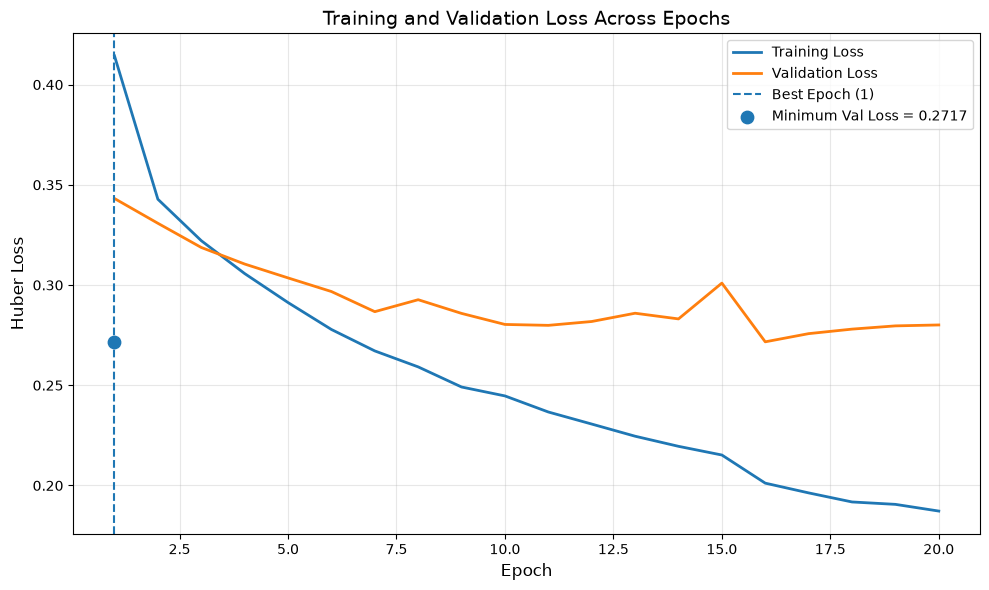

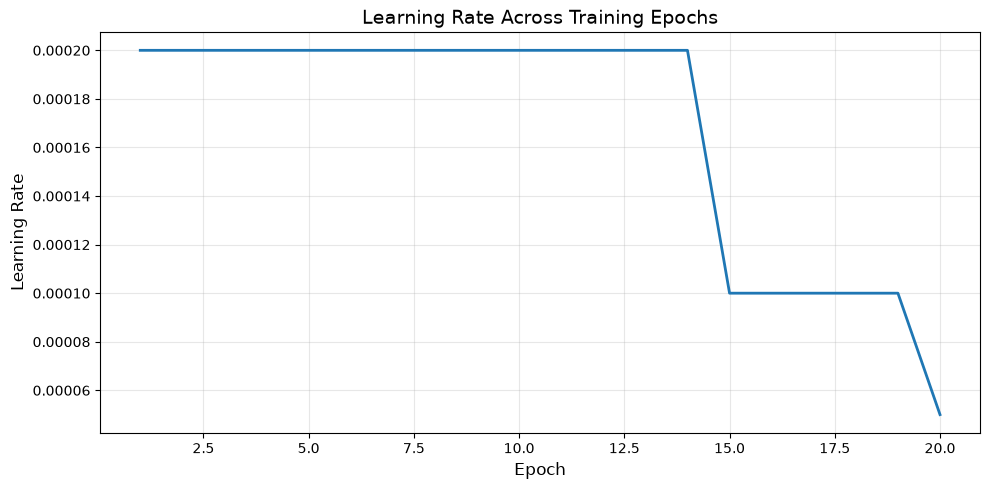

In [58]:
import pandas as pd
import matplotlib.pyplot as plt

best_epoch = 1

# ============================================================
# FINAL TRAINING HISTORY
# ============================================================


history_df = pd.read_csv("dti_training_history.csv")


print("\nTraining completed.")

print(
    f"Best validation loss: {best_val_loss:.4f}"
)

print(
    "Training history saved to: "
    "outputs/dti_training_history.csv"
)


# ============================================================
# PLOT TRAINING AND VALIDATION LOSS
# ============================================================

plt.figure(figsize=(10, 6))


# Plot training loss.
plt.plot(
    history_df["epoch"],
    history_df["train_loss"],
    label="Training Loss",
    linewidth=2
)


# Plot validation loss.
plt.plot(
    history_df["epoch"],
    history_df["val_loss"],
    label="Validation Loss",
    linewidth=2
)


# Mark the epoch at which the minimum validation loss was
# achieved.
plt.axvline(
    x=best_epoch,
    linestyle="--",
    label=f"Best Epoch ({best_epoch})"
)


# Mark the actual minimum validation-loss point.
plt.scatter(
    best_epoch,
    best_val_loss,
    s=80,
    zorder=5,
    label=f"Minimum Val Loss = {best_val_loss:.4f}"
)


plt.xlabel(
    "Epoch",
    fontsize=12
)

plt.ylabel(
    "Huber Loss",
    fontsize=12
)

plt.title(
    "Training and Validation Loss Across Epochs",
    fontsize=14
)

plt.legend()

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()


# Save publication-quality graph.
plt.savefig(
    "outputs/dti_training_validation_loss.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# PLOT LEARNING-RATE SCHEDULE
# ============================================================

plt.figure(figsize=(10, 5))

plt.plot(
    history_df["epoch"],
    history_df["learning_rate"],
    linewidth=2
)

plt.xlabel(
    "Epoch",
    fontsize=12
)

plt.ylabel(
    "Learning Rate",
    fontsize=12
)

plt.title(
    "Learning Rate Across Training Epochs",
    fontsize=14
)

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()


plt.savefig(
    "outputs/dti_learning_rate.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


Target pKi range:
-0.5431 - 13.0000

Predicted pKi range:
3.3908 - 11.3327

First 20 observed pKi values:
[9.107905  4.5641556 7.4948497 6.049635  7.464796  7.3498597 7.2006593
 5.9030895 6.259637  6.        9.39794   8.309804  8.958607  7.790485
 4.809668  7.5033517 8.        3.3261497 5.2986045 6.700283 ]

First 20 predicted pKi values:
[8.532812  6.2706475 8.053368  5.343545  7.369668  8.110754  7.2510757
 7.02221   6.30512   5.7256365 5.758282  6.1803155 7.803484  7.1505766
 6.5670533 5.5345216 5.9031725 6.031284  5.9318233 5.1298714]

TEST-SET PERFORMANCE
RMSE       : 1.1297
MAE        : 0.8669
R² Score   : 0.3857
Pearson    : 0.6268
CI         : 0.7201

Predictions saved to 'outputs/dti_test_predictions.csv'

--- Residual Analysis ---
Mean residual: 0.0571
Residual standard deviation: 1.1283
Minimum residual: -7.5694
Maximum residual: 5.5614


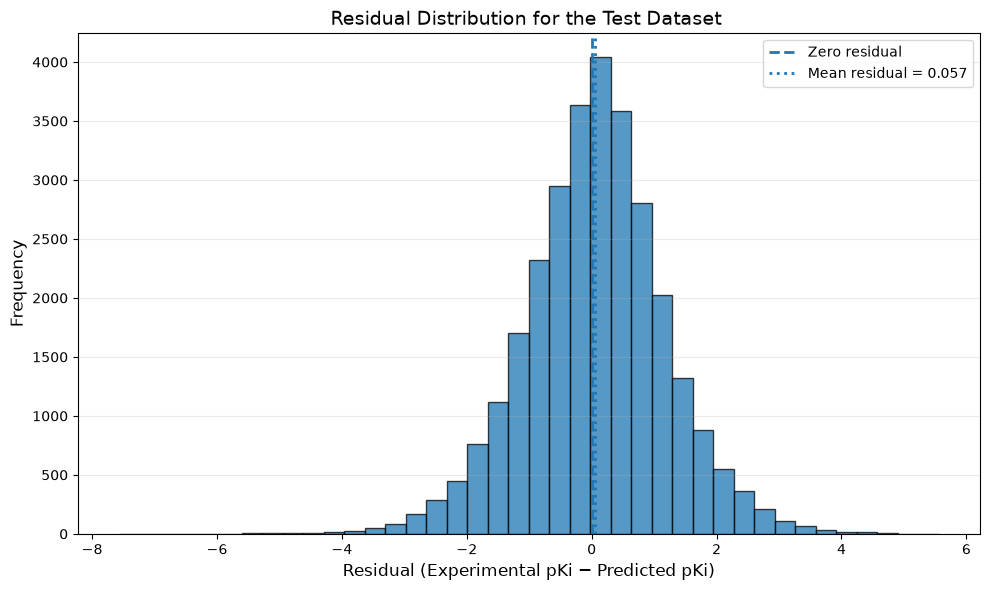

Performance metrics saved to 'outputs/dti_test_metrics.csv'


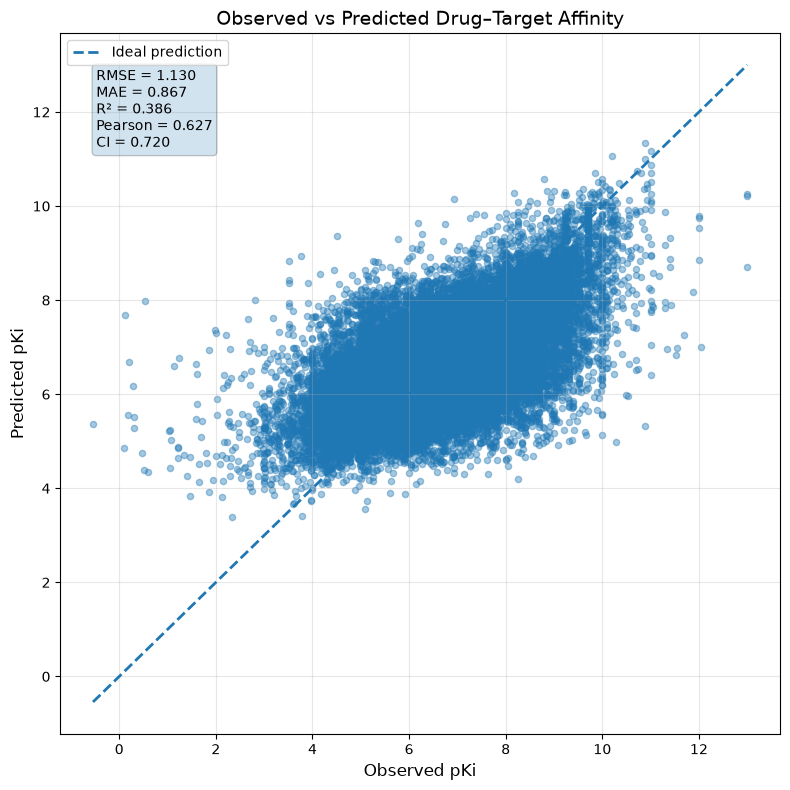

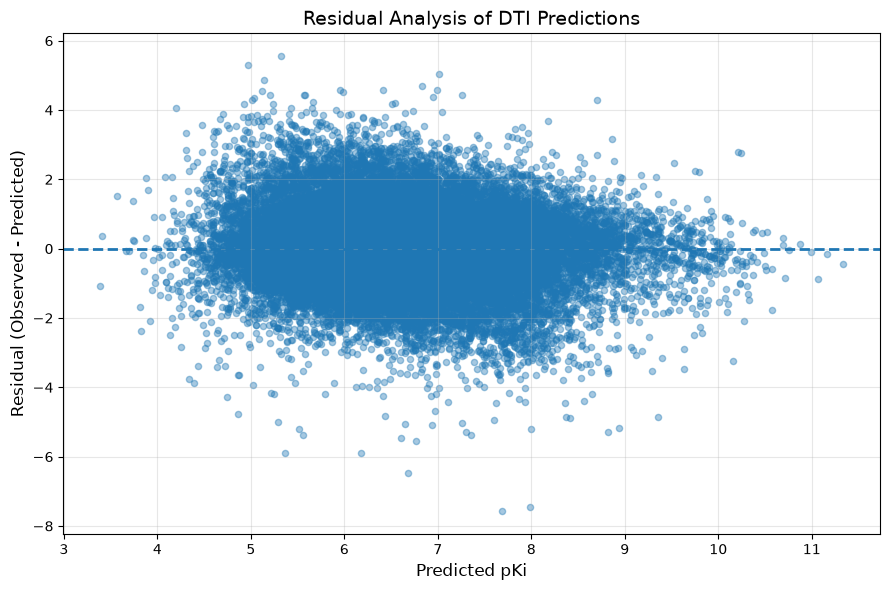

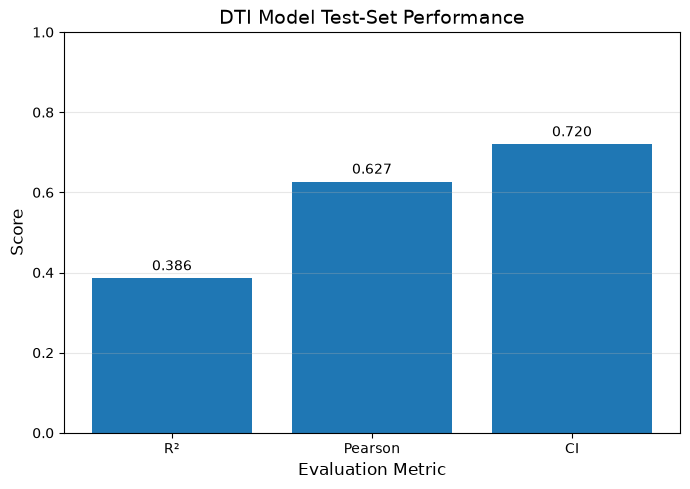

In [59]:
# ============================================================
# TEST-SET EVALUATION, CSV EXPORT AND VISUALISATION
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import pearsonr

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

from lifelines.utils import concordance_index


# ============================================================
# LOAD THE BEST MODEL CHECKPOINT
# ============================================================

# Load the parameters corresponding to the lowest validation
# loss rather than evaluating the final training epoch.
model.load_state_dict(
    torch.load(
        "best_dti_model.pt",
        map_location=device
    )
)


# Set the model to evaluation mode. This disables Dropout and
# ensures that Batch Normalisation layers use the statistics
# learned during model training.
model.eval()


# ============================================================
# GENERATE TEST-SET PREDICTIONS
# ============================================================

# Containers used to accumulate predictions and experimentally
# observed affinity values across all test mini-batches.
predictions_scaled = []
targets_scaled = []


# Gradient calculation is disabled because no model parameters
# are updated during test-set evaluation.
with torch.no_grad():

    for ligand, protein, affinity in test_loader:

        # Transfer the model inputs to the selected computational
        # device.
        ligand = ligand.to(device)
        protein = protein.to(device)


        # Generate affinity predictions for the current
        # drug-target interaction mini-batch.
        pred = model(
            ligand,
            protein
        )


        # Transfer predictions from the computational device to
        # CPU memory and convert them to NumPy arrays.
        predictions_scaled.extend(
            pred.cpu().numpy()
        )


        # Store the corresponding experimentally observed values.
        targets_scaled.extend(
            affinity.numpy()
        )


# Convert the accumulated lists into NumPy arrays.
predictions_scaled = np.asarray(predictions_scaled)
targets_scaled = np.asarray(targets_scaled)


# ============================================================
# INVERSE TRANSFORM TO ORIGINAL pKi SCALE
# ============================================================

# The model was trained using standardised pKi values.
# Consequently, both predictions and targets are converted back
# to the original pKi scale before reporting the final model
# performance.
#
# This ensures that RMSE and MAE are directly interpretable in
# pKi units.

predictions = scaler.inverse_transform(
    predictions_scaled.reshape(-1, 1)
).ravel()

targets = scaler.inverse_transform(
    targets_scaled.reshape(-1, 1)
).ravel()


# ============================================================
# BASIC PREDICTION DIAGNOSTICS
# ============================================================

print("\nTarget pKi range:")
print(
    f"{targets.min():.4f} - {targets.max():.4f}"
)

print("\nPredicted pKi range:")
print(
    f"{predictions.min():.4f} - {predictions.max():.4f}"
)

print("\nFirst 20 observed pKi values:")
print(
    targets[:20]
)

print("\nFirst 20 predicted pKi values:")
print(
    predictions[:20]
)


# ============================================================
# CALCULATE PERFORMANCE METRICS
# ============================================================

# Root Mean Squared Error (RMSE)
#
# Measures the magnitude of prediction error while placing
# greater emphasis on relatively large residuals.
rmse = np.sqrt(
    mean_squared_error(
        targets,
        predictions
    )
)


# Mean Absolute Error (MAE)
#
# Represents the average absolute difference between predicted
# and experimentally observed pKi values.
mae = mean_absolute_error(
    targets,
    predictions
)


# Coefficient of determination (R²)
#
# Measures the proportion of variation in observed pKi values
# explained by the regression model.
r2 = r2_score(
    targets,
    predictions
)


# Pearson correlation coefficient
#
# Measures the strength of the linear relationship between
# predicted and experimentally observed affinity values.
pearson_corr, pearson_p = pearsonr(
    targets,
    predictions
)


# Concordance Index (CI)
#
# Evaluates whether the predicted affinities correctly preserve
# the relative ranking of the experimentally observed affinities.
ci = concordance_index(
    targets,
    predictions
)


# ============================================================
# DISPLAY MODEL PERFORMANCE
# ============================================================

print("\n========================================")
print("TEST-SET PERFORMANCE")
print("========================================")

print(
    f"RMSE       : {rmse:.4f}"
)

print(
    f"MAE        : {mae:.4f}"
)

print(
    f"R² Score   : {r2:.4f}"
)

print(
    f"Pearson    : {pearson_corr:.4f}"
)

print(
    f"CI         : {ci:.4f}"
)


# ============================================================
# CALCULATE RESIDUALS
# ============================================================

# Residual:
#
#     observed pKi - predicted pKi
#
# A positive residual therefore indicates underprediction,
# whereas a negative residual indicates overprediction.

residuals = targets - predictions

absolute_errors = np.abs(
    residuals
)


# ============================================================
# SAVE INDIVIDUAL TEST PREDICTIONS TO CSV
# ============================================================

# Create a structured table containing the observed values,
# predictions, residuals, and absolute errors for every
# drug-target interaction in the test partition.

prediction_df = pd.DataFrame({

    "sample_id":
        np.arange(1, len(targets) + 1),

    "observed_pKi":
        targets,

    "predicted_pKi":
        predictions,

    "residual":
        residuals,

    "absolute_error":
        absolute_errors
})


prediction_df.to_csv(
    "outputs/dti_test_predictions.csv",
    index=False
)


print(
    "\nPredictions saved to "
    "'outputs/dti_test_predictions.csv'"
)

# --------------------------------------------------------
# Calculate residuals
# -----------------------------------------------------

mean_residual = np.mean(residuals)
std_residual = np.std(residuals)

print(f"\n--- Residual Analysis ---")
print(f"Mean residual: {mean_residual:.4f}")
print(f"Residual standard deviation: {std_residual:.4f}")
print(f"Minimum residual: {np.min(residuals):.4f}")
print(f"Maximum residual: {np.max(residuals):.4f}")

# --------------------------------------------------------
# Create plot
# --------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 6))

ax.hist(
    residuals,
    bins=40,
    edgecolor="black",
    alpha=0.75
)

# Perfect prediction reference line
ax.axvline(
    x=0,
    linestyle="--",
    linewidth=2,
    label="Zero residual"
)

# Mean residual
ax.axvline(
    x=mean_residual,
    linestyle=":",
    linewidth=2,
    label=f"Mean residual = {mean_residual:.3f}"
)

ax.set_xlabel(
    "Residual (Experimental pKi − Predicted pKi)",
    fontsize=12
)

ax.set_ylabel(
    "Frequency",
    fontsize=12
)

ax.set_title(
    f"Residual Distribution for the Test Dataset ",
    fontsize=14
)

ax.legend()

ax.grid(
    axis="y",
    alpha=0.25
)

plt.tight_layout()

# --------------------------------------------------------
# Save dissertation-quality image
# --------------------------------------------------------

plt.savefig(
    "outputs/dti_residual_distribution_plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()




# ============================================================
# SAVE PERFORMANCE METRICS TO CSV
# ============================================================

# Store the principal evaluation metrics in a separate file
# to facilitate reproducibility and subsequent comparison with
# baseline models or alternative data-splitting strategies.

metrics_df = pd.DataFrame({

    "Metric": [
        "RMSE",
        "MAE",
        "R2",
        "Pearson",
        "Concordance_Index"
    ],

    "Value": [
        rmse,
        mae,
        r2,
        pearson_corr,
        ci
    ]
})


metrics_df.to_csv(
    "outputs/dti_test_metrics.csv",
    index=False
)


print(
    "Performance metrics saved to "
    "'outputs/dti_test_metrics.csv'"
)


# ============================================================
# OBSERVED VS PREDICTED pKi PLOT
# ============================================================

# This scatter plot evaluates agreement between experimentally
# observed and model-predicted binding affinities.
#
# Predictions located close to the diagonal reference line
# indicate good agreement with the experimental observations.

plt.figure(
    figsize=(8, 8)
)


plt.scatter(
    targets,
    predictions,
    alpha=0.4,
    s=20
)


# Determine plotting limits using the complete observed and
# predicted pKi ranges.
minimum_value = min(
    targets.min(),
    predictions.min()
)

maximum_value = max(
    targets.max(),
    predictions.max()
)


# Add the ideal prediction line where:
#
#     predicted pKi = observed pKi
#
# A perfectly accurate model would place every observation on
# this diagonal line.
plt.plot(
    [minimum_value, maximum_value],
    [minimum_value, maximum_value],
    linestyle="--",
    linewidth=2,
    label="Ideal prediction"
)


plt.xlabel(
    "Observed pKi",
    fontsize=12
)

plt.ylabel(
    "Predicted pKi",
    fontsize=12
)

plt.title(
    "Observed vs Predicted Drug–Target Affinity",
    fontsize=14
)


# Include major performance statistics directly on the graph.
metric_text = (
    f"RMSE = {rmse:.3f}\n"
    f"MAE = {mae:.3f}\n"
    f"R² = {r2:.3f}\n"
    f"Pearson = {pearson_corr:.3f}\n"
    f"CI = {ci:.3f}"
)


plt.text(
    0.05,
    0.95,
    metric_text,
    transform=plt.gca().transAxes,
    verticalalignment="top",
    bbox=dict(
        boxstyle="round",
        alpha=0.2
    )
)


plt.legend()

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()


# Save a high-resolution image suitable for inclusion in the
# dissertation or research report.
plt.savefig(
    "outputs/dti_observed_vs_predicted.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()



# ============================================================
# RESIDUAL PLOT
# ============================================================

# The residual plot is used to examine systematic prediction
# errors. Ideally, residuals should be distributed around zero
# without a clear structural pattern.

plt.figure(
    figsize=(9, 6)
)


plt.scatter(
    predictions,
    residuals,
    alpha=0.4,
    s=20
)


# Horizontal reference line representing zero prediction error.
plt.axhline(
    y=0,
    linestyle="--",
    linewidth=2
)


plt.xlabel(
    "Predicted pKi",
    fontsize=12
)

plt.ylabel(
    "Residual (Observed - Predicted)",
    fontsize=12
)

plt.title(
    "Residual Analysis of DTI Predictions",
    fontsize=14
)

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()


plt.savefig(
    "outputs/dti_residual_plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# PERFORMANCE METRICS GRAPH
# ============================================================

# Plot selected dimensionless performance measures.
#
# RMSE and MAE are not included in this graph because they
# represent prediction errors in pKi units and therefore have
# a different interpretation from R², Pearson correlation,
# and the Concordance Index.

metric_names = [
    "R²",
    "Pearson",
    "CI"
]

metric_values = [
    r2,
    pearson_corr,
    ci
]


plt.figure(
    figsize=(7, 5)
)


bars = plt.bar(
    metric_names,
    metric_values
)


plt.ylabel(
    "Score",
    fontsize=12
)

plt.xlabel(
    "Evaluation Metric",
    fontsize=12
)

plt.title(
    "DTI Model Test-Set Performance",
    fontsize=14
)

plt.ylim(
    0,
    1
)


# Display numerical metric values above each bar.
for bar, value in zip(
    bars,
    metric_values
):

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.02,
        f"{value:.3f}",
        ha="center"
    )


plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()


plt.savefig(
    "outputs/dti_test_performance_metrics.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()



In [60]:
def collect_samples(loader, number_of_samples):

    ligand_samples = []
    protein_samples = []

    collected = 0

    for ligand, protein, _ in loader:

        remaining = number_of_samples - collected

        if remaining <= 0:
            break

        batch_size = min(
            remaining,
            ligand.shape[0]
        )

        ligand_samples.append(
            ligand[:batch_size]
            .detach()
            .cpu()
            .numpy()
            .astype(np.float32)
        )

        protein_samples.append(
            protein[:batch_size]
            .detach()
            .cpu()
            .numpy()
            .astype(np.int64)
        )

        collected += batch_size

    ligand_samples = np.concatenate(
        ligand_samples,
        axis=0
    )

    protein_samples = np.concatenate(
        protein_samples,
        axis=0
    )

    return ligand_samples, protein_samples

/Users/bikaschaudharytharu/python/Drug-target-interaction-using-machine-learning/venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Background samples: 10
Ligand dimension: 1024
Protein length: 320
Direct prediction: [ 1.2224402  -0.35640362  0.8878191  -1.0034608   0.4106412   0.92787117
  0.3278716   0.16813813 -0.33234403 -0.73678595 -0.71400124 -0.41944933
  0.7134163   0.25772965 -0.1495316  -0.8701714  -0.6128771  -0.5234639
 -0.5928808  -1.152591  ]
Wrapper prediction: [ 1.2224402  -0.35640362  0.8878191  -1.0034608   0.4106412   0.92787117
  0.3278716   0.16813813 -0.33234403 -0.73678595 -0.71400124 -0.41944933
  0.7134163   0.25772965 -0.1495316  -0.8701714  -0.6128771  -0.5234639
 -0.5928808  -1.152591  ]


100%|██████████| 20/20 [00:21<00:00,  1.10s/it]


Combined SHAP shape: (20, 1344)
Ligand SHAP shape: (20, 1024)
Protein SHAP shape: (20, 320)

Top 30 global SHAP features
 Rank         Feature Feature_Type  Mean_Abs_SHAP  Mean_Signed_SHAP
    1  Morgan_bit_136       Ligand       0.019619         -0.004308
    2  Morgan_bit_565       Ligand       0.015163          0.015163
    3  Morgan_bit_561       Ligand       0.012208          0.010329
    4  Morgan_bit_904       Ligand       0.011686          0.000273
    5  Morgan_bit_428       Ligand       0.010226          0.004541
    6  Morgan_bit_507       Ligand       0.010057          0.008121
    7   Morgan_bit_50       Ligand       0.009890         -0.009890
    8  Morgan_bit_878       Ligand       0.009617          0.005738
    9  Morgan_bit_886       Ligand       0.008950          0.005296
   10  Morgan_bit_853       Ligand       0.008773         -0.001557
   11  Morgan_bit_940       Ligand       0.008666          0.008666
   12  Morgan_bit_115       Ligand       0.008593         -0.00

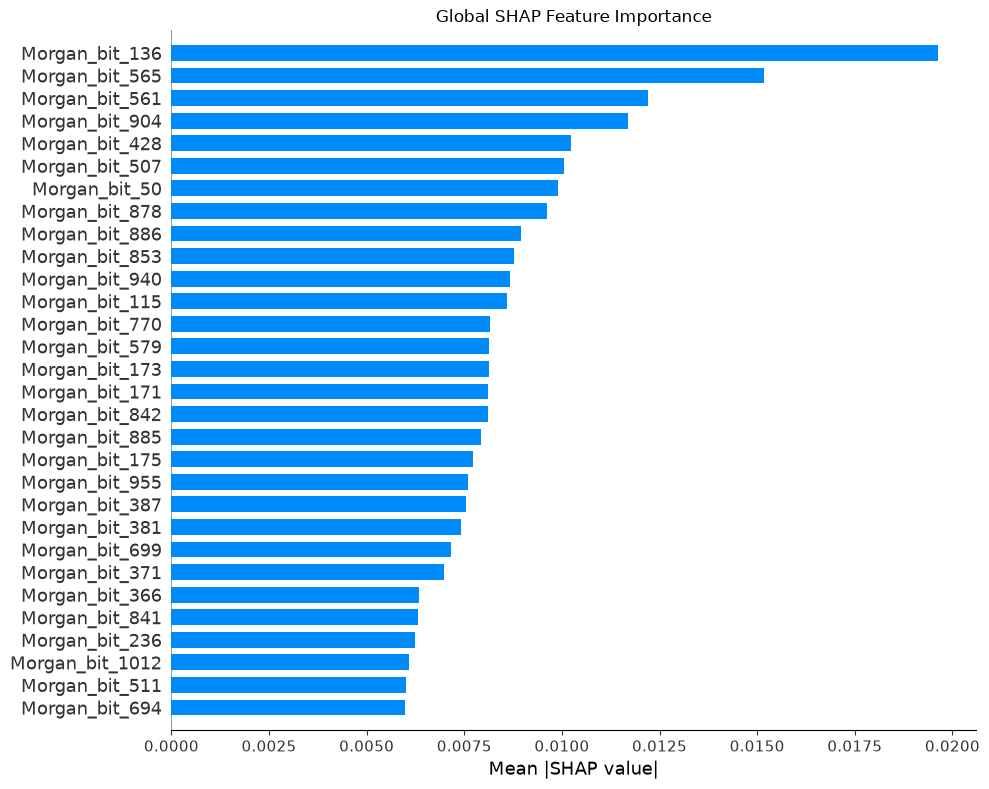

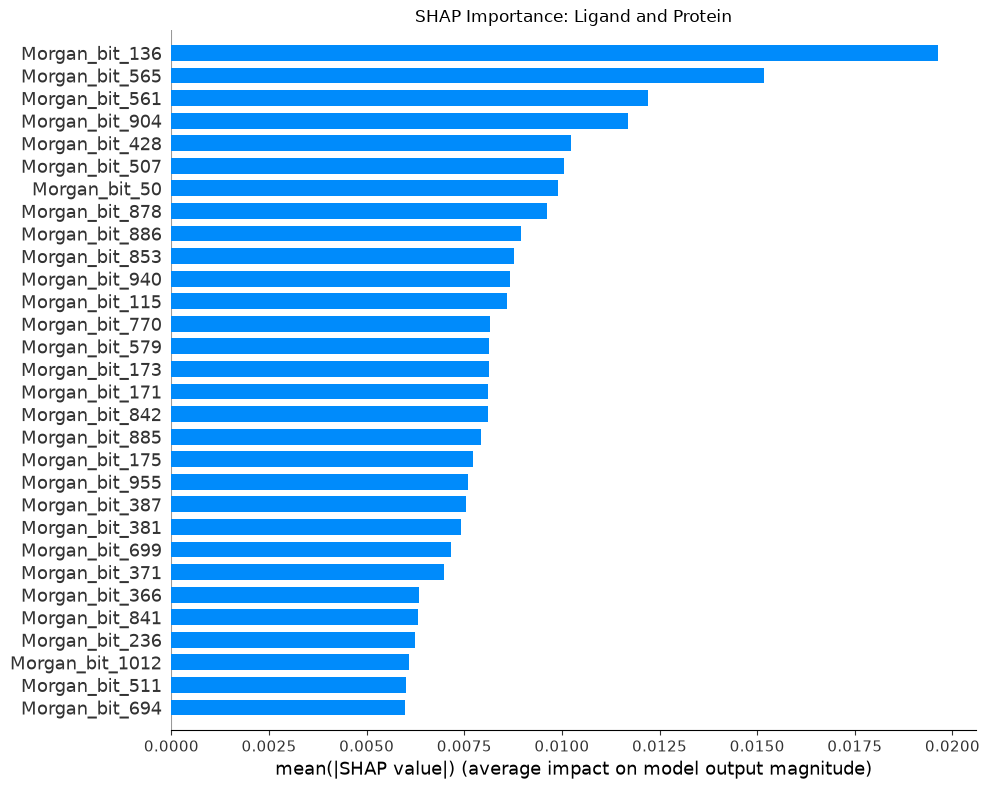

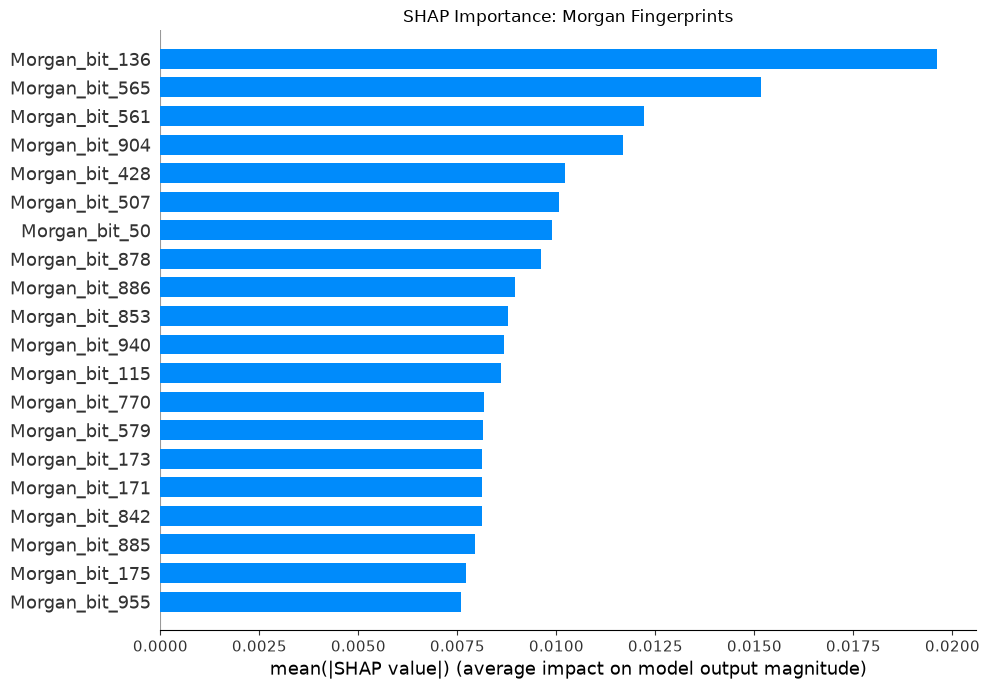

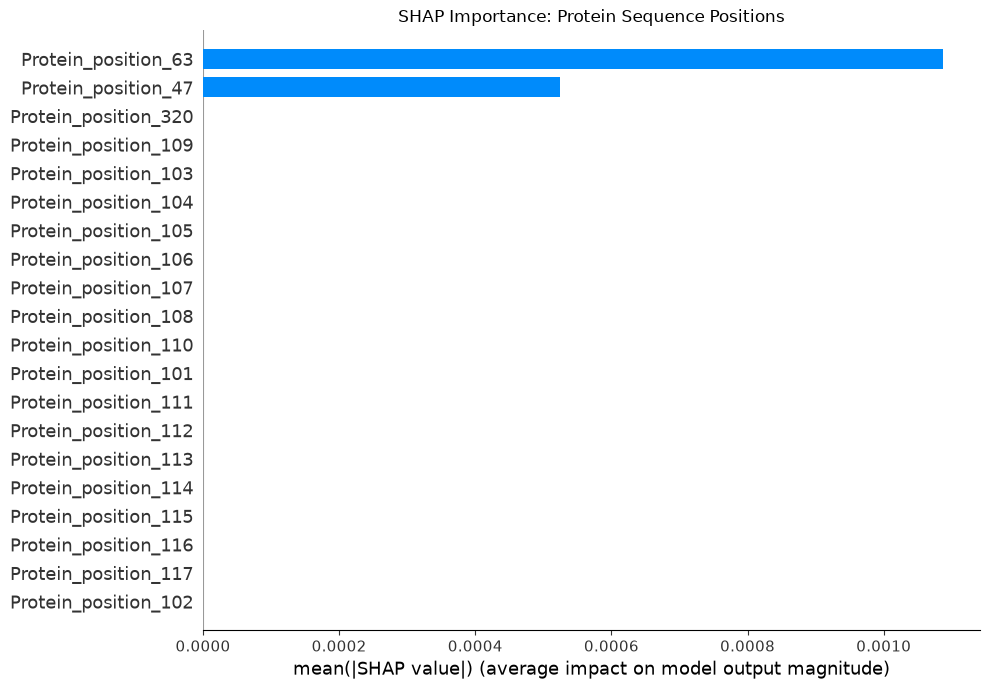

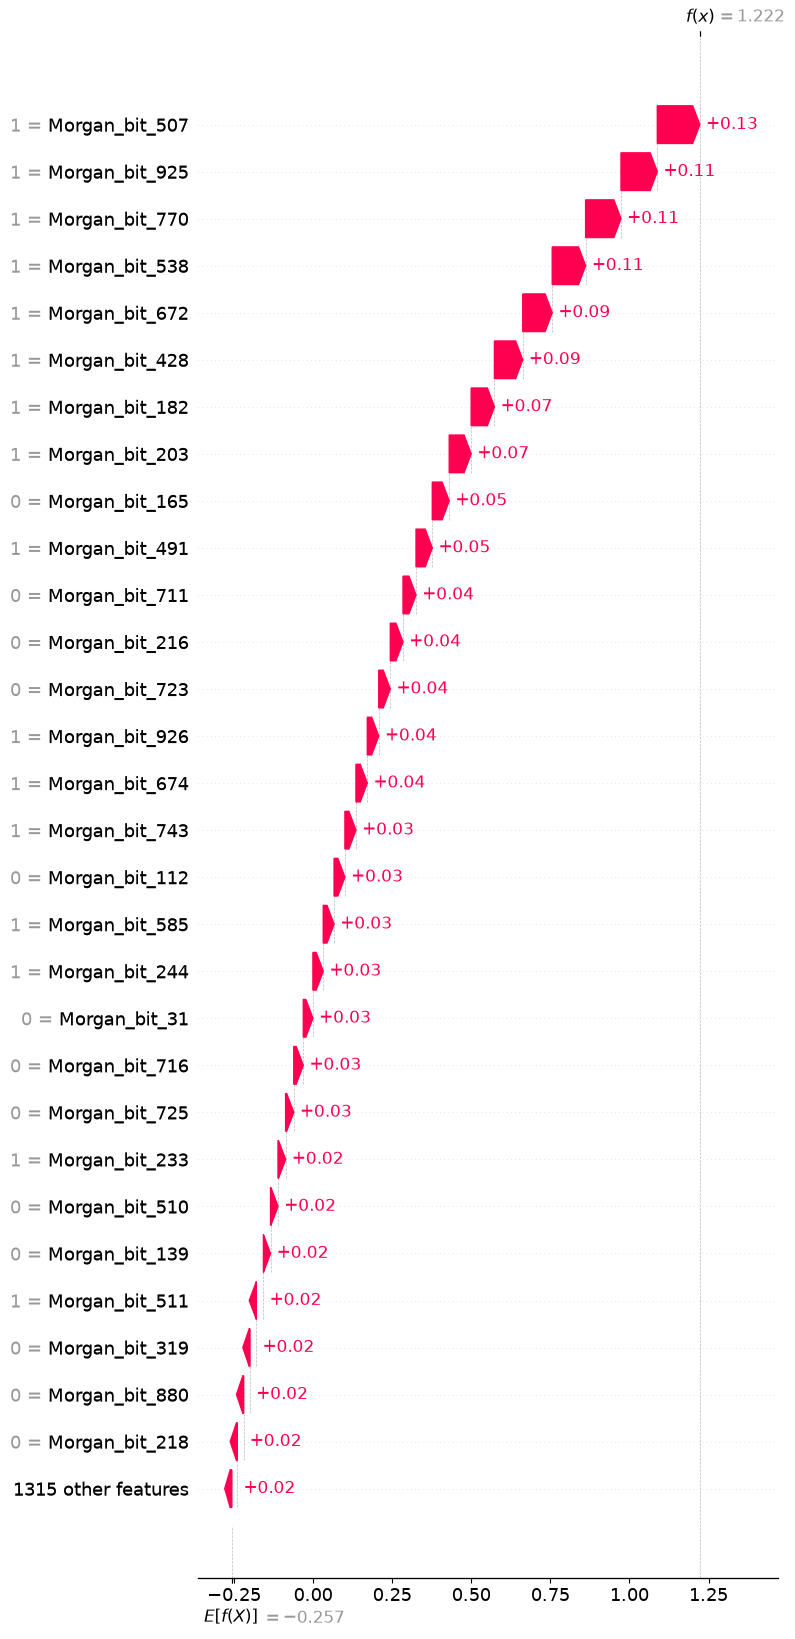

Expected value: -0.25704476907849305
Model prediction: 1.2224402
SHAP approximation: 1.222440361976623


In [61]:
# ==========================================================
# Kernel SHAP for Ligand + Integer-Encoded Protein
#
# Assumes these already exist:
#   model
#   train_loader
#   test_loader
#   device
# ==========================================================
import os
import numpy as np
import torch
import shap
import matplotlib.pyplot as plt

model.eval()

BACKGROUND_SIZE = 10
NUMBER_TO_EXPLAIN = 20
SHAP_EVALUATIONS = 500
PREDICTION_BATCH_SIZE = 256

# ==========================================================
# Background samples for Kernel SHAP
# ==========================================================

background_ligand, background_protein = collect_samples(
    train_loader,
    BACKGROUND_SIZE
)

print(
    "Background samples:",
    background_ligand.shape[0]
)

# ==========================================================
# Test samples to explain
# ==========================================================

test_ligand, test_protein = collect_samples(
    test_loader,
    NUMBER_TO_EXPLAIN
)

# ----------------------------------------------------------
# Store input dimensions
# ----------------------------------------------------------
ligand_dimension = background_ligand.shape[1]
protein_length = background_protein.shape[1]

print("Ligand dimension:", ligand_dimension)
print("Protein length:", protein_length)


# ----------------------------------------------------------
# Combine ligand and protein into one SHAP input
# ----------------------------------------------------------
background_combined = np.concatenate(
    [
        background_ligand,
        background_protein.astype(np.float32)
    ],
    axis=1
)

test_combined = np.concatenate(
    [
        test_ligand,
        test_protein.astype(np.float32)
    ],
    axis=1
)


# ----------------------------------------------------------
# Model function used by Kernel SHAP
# ----------------------------------------------------------
def predict_combined(combined_input):
    combined_input = np.asarray(
        combined_input,
        dtype=np.float32
    )

    ligand_input = combined_input[
        :,
        :ligand_dimension
    ]

    protein_input = combined_input[
        :,
        ligand_dimension:
        ligand_dimension + protein_length
    ]

    # Masking uses values from the background dataset.
    # Convert protein values back to integer token indices.
    protein_input = np.rint(
        protein_input
    ).astype(np.int64)

    predictions = []

    for start_index in range(
        0,
        combined_input.shape[0],
        PREDICTION_BATCH_SIZE
    ):
        end_index = (
            start_index
            + PREDICTION_BATCH_SIZE
        )

        ligand_batch = torch.tensor(
            ligand_input[start_index:end_index],
            dtype=torch.float32,
            device=device
        )

        protein_batch = torch.tensor(
            protein_input[start_index:end_index],
            dtype=torch.long,
            device=device
        )

        with torch.no_grad():
            batch_prediction = model(
                ligand_batch,
                protein_batch
            )

        predictions.append(
            batch_prediction
            .detach()
            .cpu()
            .numpy()
            .reshape(-1)
        )

    return np.concatenate(
        predictions,
        axis=0
    )


# ----------------------------------------------------------
# Verify the combined prediction function
# ----------------------------------------------------------
direct_ligand = torch.tensor(
    test_ligand,
    dtype=torch.float32,
    device=device
)

direct_protein = torch.tensor(
    test_protein,
    dtype=torch.long,
    device=device
)

with torch.no_grad():
    direct_prediction = model(
        direct_ligand,
        direct_protein
    ).detach().cpu().numpy().reshape(-1)


wrapper_prediction = predict_combined(
    test_combined
)

print("Direct prediction:", direct_prediction)
print("Wrapper prediction:", wrapper_prediction)

assert np.allclose(
    direct_prediction,
    wrapper_prediction,
    atol=1e-5
), "Combined wrapper prediction does not match the model."


# ----------------------------------------------------------
# Feature names
# ----------------------------------------------------------
ligand_feature_names = [
    f"Morgan_bit_{index}"
    for index in range(ligand_dimension)
]

protein_feature_names = [
    f"Protein_position_{index + 1}"
    for index in range(protein_length)
]

combined_feature_names = (
    ligand_feature_names
    + protein_feature_names
)


# ----------------------------------------------------------
# Create Kernel SHAP explainer
# ----------------------------------------------------------
explainer = shap.KernelExplainer(
    model=predict_combined,
    data=background_combined,
    feature_names=combined_feature_names,
    link="identity"
)


# ----------------------------------------------------------
# Calculate SHAP values
# ----------------------------------------------------------
shap_values = explainer.shap_values(
    test_combined,
    nsamples=SHAP_EVALUATIONS,
    l1_reg="num_features(30)",
    silent=False
)

if isinstance(shap_values, list):
    shap_values = shap_values[0]

shap_values = np.asarray(shap_values)

if shap_values.ndim == 3 and shap_values.shape[-1] == 1:
    shap_values = shap_values[:, :, 0]

print("Combined SHAP shape:", shap_values.shape)


# ----------------------------------------------------------
# Separate ligand and protein SHAP values
# ----------------------------------------------------------
ligand_shap_values = shap_values[
    :,
    :ligand_dimension
]

protein_shap_values = shap_values[
    :,
    ligand_dimension:
    ligand_dimension + protein_length
]

print(
    "Ligand SHAP shape:",
    ligand_shap_values.shape
)

print(
    "Protein SHAP shape:",
    protein_shap_values.shape
)








# ==========================================================
# GLOBAL EXPLANATION
# Mean Absolute SHAP Importance
# ==========================================================

# Global feature importance is calculated by averaging
# the absolute SHAP values across all explained samples.

global_mean_abs_shap = np.mean(
    np.abs(shap_values),
    axis=0
)

# Mean signed contribution can also be retained,
# although it should not be used alone as global importance
# because positive and negative contributions may cancel.

global_mean_signed_shap = np.mean(
    shap_values,
    axis=0
)


# ==========================================================
# Feature types
# ==========================================================

feature_types = (
    ["Ligand"] * ligand_dimension
    +
    ["Protein"] * protein_length
)


# ==========================================================
# Global importance DataFrame
# ==========================================================

global_importance_df = pd.DataFrame(
    {
        "Feature": combined_feature_names,
        "Feature_Type": feature_types,
        "Mean_Abs_SHAP": global_mean_abs_shap,
        "Mean_Signed_SHAP": global_mean_signed_shap
    }
)

global_importance_df = (
    global_importance_df
    .sort_values(
        "Mean_Abs_SHAP",
        ascending=False
    )
    .reset_index(drop=True)
)

global_importance_df.insert(
    0,
    "Rank",
    np.arange(
        1,
        len(global_importance_df) + 1
    )
)


# ==========================================================
# Save global SHAP table
# ==========================================================

global_importance_df.to_csv(
    os.path.join(
        "outputs/",
        "global_shap_feature_importance.csv"
    ),
    index=False
)

print("\nTop 30 global SHAP features")
print("===========================")

print(
    global_importance_df.head(30).to_string(
        index=False
    )
)


# ==========================================================
# GLOBAL PLOT 1
# SHAP combined summary bar plot
# ==========================================================

shap.summary_plot(
    shap_values,
    test_combined,
    feature_names=combined_feature_names,
    plot_type="bar",
    max_display=30,
    plot_size=(10, 8),
    show=False
)

plt.title(
    "Global SHAP Feature Importance"
)

plt.xlabel(
    "Mean |SHAP value|"
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        "outputs/",
        "global_shap_combined_summary.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()





# ==========================================================
# Combined SHAP importance plot
# ==========================================================
shap.summary_plot(
    shap_values,
    test_combined,
    feature_names=combined_feature_names,
    plot_type="bar",
    max_display=30,
    plot_size=(10, 8),
    show=False
)

plt.title("SHAP Importance: Ligand and Protein")
plt.tight_layout()

plt.savefig(
    "shap_combined_summary.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()


# ==========================================================
# Ligand SHAP plot
# ==========================================================
shap.summary_plot(
    ligand_shap_values,
    test_ligand,
    feature_names=ligand_feature_names,
    plot_type="bar",
    max_display=20,
    plot_size=(10, 7),
    show=False
)

plt.title("SHAP Importance: Morgan Fingerprints")
plt.tight_layout()

plt.savefig(
    "shap_ligand_summary.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()


# ==========================================================
# Protein SHAP plot
# ==========================================================
shap.summary_plot(
    protein_shap_values,
    test_protein,
    feature_names=protein_feature_names,
    plot_type="bar",
    max_display=20,
    plot_size=(10, 7),
    show=False
)

plt.title("SHAP Importance: Protein Sequence Positions")
plt.tight_layout()

plt.savefig(
    "shap_protein_summary.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()


# ==========================================================
# Combined waterfall plot
# ==========================================================
sample_index = 0

base_value = float(
    np.asarray(
        explainer.expected_value
    ).reshape(-1)[0]
)

explanation = shap.Explanation(
    values=shap_values[sample_index],
    base_values=base_value,
    data=test_combined[sample_index],
    feature_names=combined_feature_names
)

shap.plots.waterfall(
    explanation,
    max_display=30,
    show=False
)

plt.tight_layout()

plt.savefig(
    "shap_combined_waterfall.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()


# ----------------------------------------------------------
# Verify SHAP additivity
# ----------------------------------------------------------
shap_approximation = (
    base_value
    + shap_values[sample_index].sum()
)

print("Expected value:", base_value)
print(
    "Model prediction:",
    wrapper_prediction[sample_index]
)
print(
    "SHAP approximation:",
    shap_approximation
)

In [62]:
from lifelines.utils import concordance_index

ci = concordance_index(
    targets,
    predictions
)

print(f"CI: {ci:.4f}")

CI: 0.7201


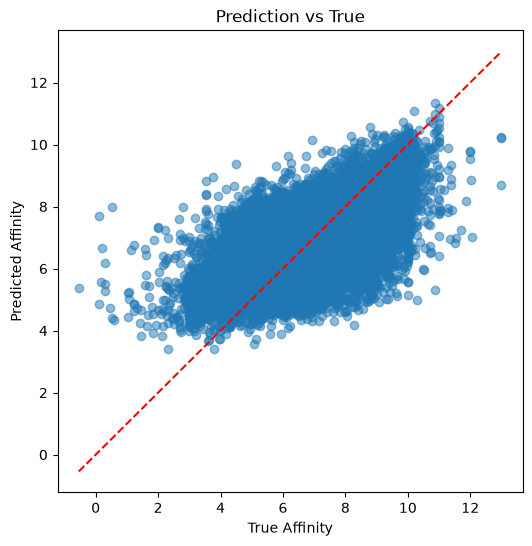

In [63]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(targets, predictions, alpha=0.5)

plt.plot(
    [targets.min(), targets.max()],
    [targets.min(), targets.max()],
    'r--'
)

plt.xlabel("True Affinity")
plt.ylabel("Predicted Affinity")
plt.title("Prediction vs True")
plt.show()

In [64]:
model = DTIRegressor().to(device)

In [65]:
model.load_state_dict(
    torch.load(
        "best_dti_model.pt",
        map_location=device,
        weights_only=True
    )
)

<All keys matched successfully>

In [66]:
model.eval()

DTIRegressor(
  (ligand_encoder): Sequential(
    (0): Linear(in_features=1024, out_features=512, bias=True)
    (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=256, out_features=128, bias=True)
    (9): ReLU()
  )
  (protein_embedding): Embedding(22, 128, padding_idx=0)
  (protein_encoder): Sequential(
    (0): Conv1d(128, 128, kernel_size=(5,), stride=(1,), padding=(2,))
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Conv1d(128, 128, kernel_size=(5,), stride=(1,), padding=(2,))
    (5): BatchNorm1d(128, eps=1e-05, momentum=0

In [69]:
def evaluate_split(model, loader, criterion, device):
    model.eval()

    predictions = []
    targets = []

    with torch.no_grad():
        for ligand, protein, y in loader:
            ligand = ligand.to(device)
            protein = protein.to(device)
            y = y.to(device)

            output = model(ligand, protein)

            predictions.extend(output.cpu().numpy())
            targets.extend(y.cpu().numpy())

    predictions = np.asarray(predictions)
    targets = np.asarray(targets)

    rmse = np.sqrt(mean_squared_error(targets, predictions))
    mae = mean_absolute_error(targets, predictions)
    r2 = r2_score(targets, predictions)
    pearson = np.corrcoef(targets, predictions)[0, 1]
    ci = concordance_index(
            targets,
            predictions
        )

    return {
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2,
        "Pearson": pearson,
        "CI": ci
    }
# Train: {'RMSE': np.float64(0.42871898391575997), 'MAE': 0.3087441921234131, 'R2': 0.8162000179290771, 'Pearson': np.float64(0.9106309977820247)}
# Validation: {'RMSE': np.float64(0.7877771086802807), 'MAE': 0.5996342897415161, 'R2': 0.3778798580169678, 'Pearson': np.float64(0.6261924654509952)}
# Test: {'RMSE': np.float64(0.7947358984690636), 'MAE': 0.6037222743034363, 'R2': 0.37590640783309937, 'Pearson': np.float64(0.6248231585487828)}

train_results = evaluate_split(model, train_loader, loss_fn, device)
val_results = evaluate_split(model, val_loader, loss_fn, device)
test_results = evaluate_split(model, test_loader, loss_fn, device)

print("Train:", train_results)
print("Validation:", val_results)
print("Test:", test_results)


Train: {'RMSE': np.float64(0.5313854044970446), 'MAE': 0.3952539265155792, 'R2': 0.7176295518875122, 'Pearson': np.float64(0.8522845435520274), 'CI': np.float64(0.8377969518230485)}
Validation: {'RMSE': np.float64(0.7804245211695989), 'MAE': 0.6012679934501648, 'R2': 0.38943856954574585, 'Pearson': np.float64(0.6292438534074494), 'CI': np.float64(0.7201383988037968)}
Test: {'RMSE': np.float64(0.7884782195339598), 'MAE': 0.6050172448158264, 'R2': 0.38569581508636475, 'Pearson': np.float64(0.6267579776791675), 'CI': np.float64(0.7201285382358933)}


In [34]:
model = DTIRegressor(
    # use exactly the same architecture arguments
)

model.load_state_dict(
    torch.load(
        "best_dti_model.pt",
        map_location=device
    )
)

model = model.to(device)
model.eval()

DTIRegressor(
  (ligand_encoder): Sequential(
    (0): Linear(in_features=1024, out_features=512, bias=True)
    (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=256, out_features=128, bias=True)
    (9): ReLU()
  )
  (protein_embedding): Embedding(22, 128, padding_idx=0)
  (protein_encoder): Sequential(
    (0): Conv1d(128, 128, kernel_size=(5,), stride=(1,), padding=(2,))
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Conv1d(128, 128, kernel_size=(5,), stride=(1,), padding=(2,))
    (5): BatchNorm1d(128, eps=1e-05, momentum=0

In [35]:
import numpy as np
import torch

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)


# ============================================================
# Predict an entire split at once
# ============================================================

def predict_split(
    model,
    loader,
    device,
    y_scaler=None
):
    """
    Generate predictions and collect targets for one complete
    dataset split.

    If y_scaler is provided, both predictions and targets are
    inverse-transformed back to the original pKi scale.
    """

    model.eval()

    predictions = []
    targets = []

    with torch.no_grad():

        for ligand, protein, y in loader:

            ligand = ligand.to(device)
            protein = protein.to(device)

            # Forward pass
            output = model(
                ligand,
                protein
            )

            # Convert to 1D NumPy arrays
            predictions.append(
                output.detach().cpu().numpy().ravel()
            )

            targets.append(
                y.detach().cpu().numpy().ravel()
            )

    # --------------------------------------------------------
    # Combine all batches
    # --------------------------------------------------------

    predictions = np.concatenate(
        predictions
    )

    targets = np.concatenate(
        targets
    )

    # --------------------------------------------------------
    # Convert scaled values back to original pKi
    # --------------------------------------------------------

    if y_scaler is not None:

        predictions = y_scaler.inverse_transform(
            predictions.reshape(-1, 1)
        ).ravel()

        targets = y_scaler.inverse_transform(
            targets.reshape(-1, 1)
        ).ravel()

    return targets, predictions

In [36]:
# ============================================================
# Evaluate predictions
# ============================================================

def evaluate_predictions(
    targets,
    predictions
):

    targets = np.asarray(
        targets
    ).ravel()

    predictions = np.asarray(
        predictions
    ).ravel()

    mse = mean_squared_error(
        targets,
        predictions
    )

    rmse = np.sqrt(mse)

    mae = mean_absolute_error(
        targets,
        predictions
    )

    r2 = r2_score(
        targets,
        predictions
    )

    # --------------------------------------------------------
    # Pearson correlation
    # --------------------------------------------------------

    if (
        len(targets) > 1
        and np.std(targets) > 0
        and np.std(predictions) > 0
    ):
        pearson = np.corrcoef(
            targets,
            predictions
        )[0, 1]
    else:
        pearson = np.nan

    # --------------------------------------------------------
    # Concordance Index
    # --------------------------------------------------------

    # ci = concordance_index(
    #     targets,
    #     predictions
    # )

    return {
        "MSE": mse,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2,
        "Pearson": pearson,
        # "CI": ci
    }

In [44]:
# ============================================================
# Generate predictions ONCE
# ============================================================

y_train_true, y_train_pred = predict_split(
    model,
    train_loader,
    device,
    y_scaler=scaler
)

y_val_true, y_val_pred = predict_split(
    model,
    val_loader,
    device,
    y_scaler=scaler
)

y_test_true, y_test_pred = predict_split(
    model,
    test_loader,
    device,
    y_scaler=scaler
)

In [45]:
# ============================================================
# Evaluate
# ============================================================

train_results = evaluate_predictions(
    y_train_true,
    y_train_pred
)

val_results = evaluate_predictions(
    y_val_true,
    y_val_pred
)

test_results = evaluate_predictions(
    y_test_true,
    y_test_pred
)


print("Train:", train_results)
print("Validation:", val_results)
print("Test:", test_results)

Train: {'MSE': 0.5796814560890198, 'RMSE': np.float64(0.7613681475403471), 'MAE': 0.5663192272186279, 'R2': 0.7176295518875122, 'Pearson': np.float64(0.8522845442485347)}
Validation: {'MSE': 1.250351071357727, 'RMSE': np.float64(1.1181909816116955), 'MAE': 0.8614959120750427, 'R2': 0.3894385099411011, 'Pearson': np.float64(0.6292438551283187)}
Test: {'MSE': 1.2762905359268188, 'RMSE': np.float64(1.1297302934447757), 'MAE': 0.8668677806854248, 'R2': 0.3856958746910095, 'Pearson': np.float64(0.6267579780017651)}
